<a href="https://colab.research.google.com/github/Rimsha2803/data-analytics-portfolio/blob/main/sarima-forecast/Task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from google.colab import files

In [ ]:
uploaded = files.upload()
df = pd.read_csv('online_retail_cleaned.csv', low_memory=False)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']
invoice_df = df.groupby('InvoiceNo').agg(
    InvoiceDate=('InvoiceDate', 'first'),
    Country=('Country', 'first'),
    OrderValue=('Revenue', 'sum')
).reset_index()

invoice_df['DayOfWeek'] = invoice_df['InvoiceDate'].dt.dayofweek
invoice_df['IsWeekend'] = invoice_df['DayOfWeek'] >= 5

invoice_df.shape

Saving online_retail_cleaned.csv to online_retail_cleaned.csv


(19960, 6)

In [ ]:
weekday_orders = invoice_df[~invoice_df['IsWeekend']]['OrderValue']
weekend_orders = invoice_df[invoice_df['IsWeekend']]['OrderValue']

t_stat, p_val = stats.ttest_ind(weekday_orders, weekend_orders, equal_var=False)

print(f"Weekday: mean={weekday_orders.mean():.2f}, n={len(weekday_orders)}")
print(f"Weekend: mean={weekend_orders.mean():.2f}, n={len(weekend_orders)}")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")

Weekday: mean=553.92, n=17756
Weekend: mean=366.06, n=2204
t-statistic: 10.3383, p-value: 0.0000


In [ ]:
top_countries = invoice_df['Country'].value_counts().head(5).index.tolist()
groups = [invoice_df[invoice_df['Country']==c]['OrderValue'] for c in top_countries]

f_stat, p_val_anova = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val_anova:.4f}")

for c, g in zip(top_countries, groups):
    print(f"{c}: mean={g.mean():.2f}, n={len(g)}")

F-statistic: 5.5591, p-value: 0.0002
United Kingdom: mean=499.57, n=18019
Germany: mean=500.39, n=457
France: mean=534.76, n=392
EIRE: mean=983.13, n=288
Belgium: mean=420.37, n=98


In [ ]:
h_stat, p_val_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis H: {h_stat:.4f}, p-value: {p_val_kw:.4f}")

Kruskal-Wallis H: 248.9697, p-value: 0.0000


In [ ]:
invoice_outlier = df.groupby('InvoiceNo')['qty_outlier'].any().reset_index()
invoice_outlier.rename(columns={'qty_outlier': 'HasBulkItem'}, inplace=True)
invoice_df = invoice_df.merge(invoice_outlier, on='InvoiceNo', how='left')

top5_df = invoice_df[invoice_df['Country'].isin(top_countries)]
contingency = pd.crosstab(top5_df['Country'], top5_df['HasBulkItem'])
print(contingency)

chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi2: {chi2:.4f}, p-value: {p_val_chi2:.4f}, dof: {dof}")

HasBulkItem     False  True 
Country                     
Belgium            36     62
EIRE               59    229
France             96    296
Germany           139    318
United Kingdom   6631  11388
Chi2: 63.5252, p-value: 0.0000, dof: 4


In [ ]:
invoice_df['DayOfWeek'].value_counts()

,count
DayOfWeek,
3,4246
2,3690
1,3554
4,3140
0,3126
6,2204


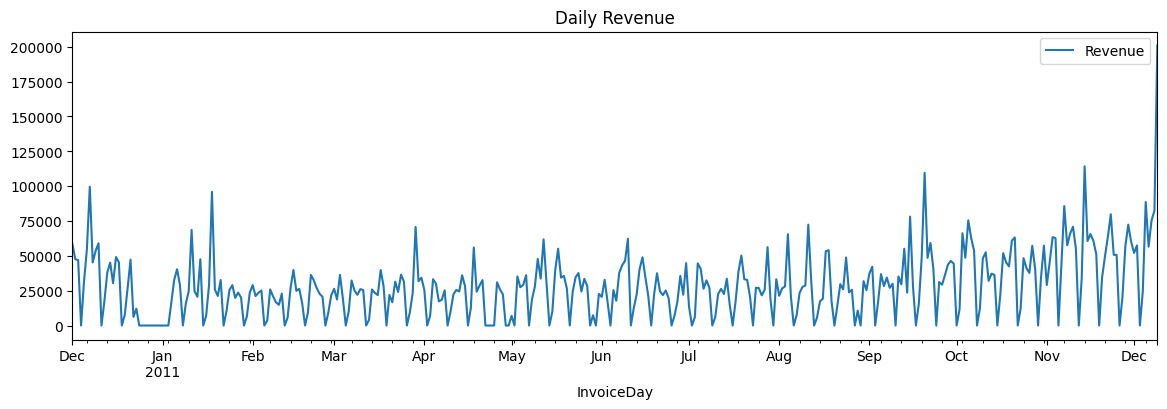

(374, 1)


In [ ]:
df['InvoiceDay'] = df['InvoiceDate'].dt.date
daily_revenue = df.groupby('InvoiceDay')['Revenue'].sum().reset_index()
daily_revenue['InvoiceDay'] = pd.to_datetime(daily_revenue['InvoiceDay'])
daily_revenue = daily_revenue.set_index('InvoiceDay').asfreq('D')

# Saturdays showing as missing here are genuinely zero-revenue days, not
# a data error — filling with 0 is the correct call given what we just found
daily_revenue['Revenue'] = daily_revenue['Revenue'].fillna(0)

daily_revenue.plot(figsize=(14,4), title='Daily Revenue')
plt.show()

print(daily_revenue.shape)

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_revenue['Revenue'])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")


ADF Statistic: -0.6417
p-value: 0.8613


In [ ]:
zero_days = daily_revenue[daily_revenue['Revenue'] == 0]
print(zero_days)

            Revenue
InvoiceDay         
2010-12-04      0.0
2010-12-11      0.0
2010-12-18      0.0
2010-12-24      0.0
2010-12-25      0.0
...             ...
2011-11-05      0.0
2011-11-12      0.0
2011-11-19      0.0
2011-11-26      0.0
2011-12-03      0.0

[69 rows x 1 columns]


In [ ]:
daily_revenue.tail(10)

,Revenue
InvoiceDay,
2011-11-30,60025.57
2011-12-01,52068.63
2011-12-02,57476.48
2011-12-03,0.00
2011-12-04,24477.47
2011-12-05,88620.84
2011-12-06,56558.83
2011-12-07,75315.55
2011-12-08,82371.55


In [ ]:
zero_days.index.dayofweek.value_counts()

,count
InvoiceDay,
5,53
0,6
4,4
6,3
1,1
2,1
3,1


In [ ]:
last_day_invoices = df[df['InvoiceDate'].dt.date == pd.Timestamp('2011-12-09').date()]['InvoiceNo'].nunique()
typical_invoices = df.groupby(df['InvoiceDate'].dt.date)['InvoiceNo'].nunique().mean()

print(f"Invoices on Dec 9: {last_day_invoices}")
print(f"Average invoices per day: {typical_invoices:.1f}")

Invoices on Dec 9: 44
Average invoices per day: 65.4


In [ ]:
train = daily_revenue.iloc[:-30]
test = daily_revenue.iloc[-30:]

print(f"Train: {train.index.min()} to {train.index.max()} ({len(train)} days)")
print(f"Test: {test.index.min()} to {test.index.max()} ({len(test)} days)")

Train: 2010-12-01 00:00:00 to 2011-11-09 00:00:00 (344 days)
Test: 2011-11-10 00:00:00 to 2011-12-09 00:00:00 (30 days)


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['Revenue'],
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results = model.fit(disp=False)
print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           Revenue   No. Observations:                  344
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -3590.100
Date:                           Sun, 16 Aug 2026   AIC                           7190.200
Time:                                   07:02:12   BIC                           7209.149
Sample:                               12-01-2010   HQIC                          7197.761
                                    - 11-09-2011                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0009      0.108     -0.008      0.993      -0.213       0.211
ma.L1         -0.7020      0.076     -9.267

In [ ]:
model2 = SARIMAX(
    train['Revenue'],
    order=(0,1,1),
    seasonal_order=(0,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results2 = model2.fit(disp=False)
print(results2.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           Revenue   No. Observations:                  344
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 7)   Log Likelihood               -3592.283
Date:                           Sun, 16 Aug 2026   AIC                           7190.565
Time:                                   07:02:12   BIC                           7201.935
Sample:                               12-01-2010   HQIC                          7195.102
                                    - 11-09-2011                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7014      0.057    -12.328      0.000      -0.813      -0.590
ma.S.L7       -0.7574      0.039    -19.392

In [ ]:
train_scaled = train['Revenue'] / 1000
test_scaled = test['Revenue'] / 1000

model3 = SARIMAX(
    train_scaled,
    order=(0,1,1),
    seasonal_order=(0,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
results3 = model3.fit(disp=False)
print(results3.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           Revenue   No. Observations:                  344
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 7)   Log Likelihood               -1309.891
Date:                           Sun, 16 Aug 2026   AIC                           2625.783
Time:                                   07:03:39   BIC                           2637.153
Sample:                               12-01-2010   HQIC                          2630.320
                                    - 11-09-2011                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7762      0.037    -21.143      0.000      -0.848      -0.704
ma.S.L7       -0.8828      0.032    -27.953

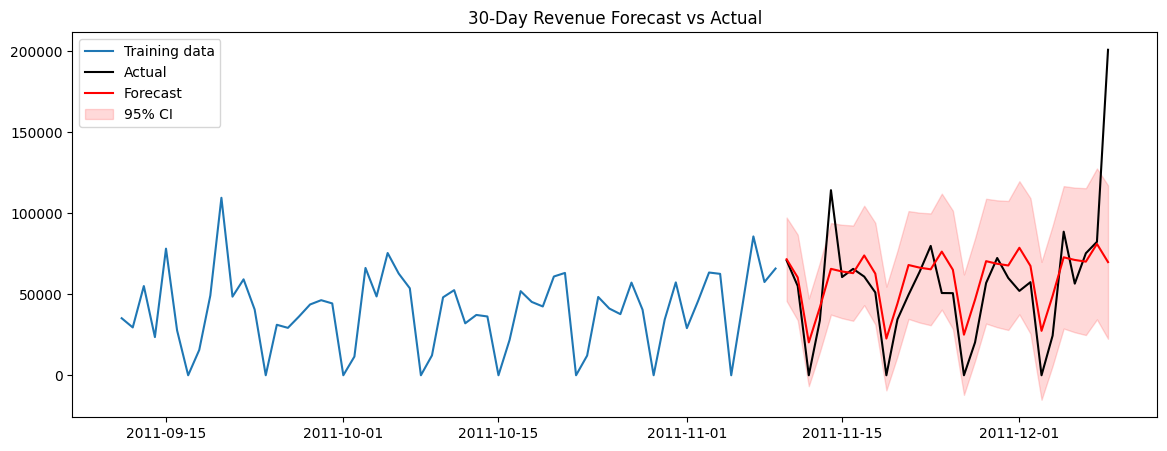

In [ ]:
forecast = results3.get_forecast(steps=30)
forecast_mean = forecast.predicted_mean * 1000  # scale back to real £
conf_int = forecast.conf_int() * 1000

plt.figure(figsize=(14,5))
plt.plot(train.index[-60:], train['Revenue'].iloc[-60:], label='Training data')
plt.plot(test.index, test['Revenue'], label='Actual', color='black')
plt.plot(test.index, forecast_mean, label='Forecast', color='red')
plt.fill_between(test.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='red', alpha=0.15, label='95% CI')
plt.legend()
plt.title('30-Day Revenue Forecast vs Actual')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test['Revenue'], forecast_mean)
rmse = np.sqrt(mean_squared_error(test['Revenue'], forecast_mean))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"Mean actual revenue in test period: {test['Revenue'].mean():.2f}")

MAE: 18475.12
RMSE: 29787.00
Mean actual revenue in test period: 56306.64


In [ ]:
errors = np.abs(test['Revenue'] - forecast_mean)
print(errors.sort_values(ascending=False).head(5))

mae_excl = mean_absolute_error(test['Revenue'][:-1], forecast_mean[:-1])
rmse_excl = np.sqrt(mean_squared_error(test['Revenue'][:-1], forecast_mean[:-1]))
print(f"MAE excluding Dec 9: {mae_excl:.2f}")
print(f"RMSE excluding Dec 9: {rmse_excl:.2f}")

InvoiceDay
2011-12-09    131046.992623
2011-11-14     48552.509847
2011-12-03     27419.713780
2011-12-01     26628.046730
2011-11-27     26376.472257
dtype: float64
MAE excluding Dec 9: 14593.33
RMSE excluding Dec 9: 18046.54


In [ ]:
print(conf_int.iloc[:,0].min())

-15124.267495502558


### Task 4: Hypothesis Testing & Revenue Forecasting

**Hypothesis Testing**

An independent samples t-test (Welch's) found order values differ
significantly by day of week (t=10.34, p<0.0001). Initial framing as
"weekend vs weekday" was corrected after finding zero orders occur on
Saturdays in this dataset — the effect actually reflects weekdays
(mean=£553.92, n=17,756) versus Sunday only (mean=£366.06, n=2,204).

An ANOVA across the top 5 countries by order volume found a significant
difference in order value (F=5.56, p=0.0002), confirmed by a Kruskal-
Wallis test (H=248.97, p<0.0001) given the skewed, unbalanced group
sizes. EIRE stood out with a mean order value of £983 — roughly double
every other country (UK £500, Germany £500, France £535, Belgium £420).

A Chi-Square test found country is significantly associated with
placing above-typical-quantity orders (χ²=63.53, p<0.0001). EIRE had
the highest rate (~80% of orders), followed by France (~76%), versus
UK and Belgium (~63%). This connects directly to the ANOVA result:
EIRE's elevated average order value is plausibly explained by its
higher rate of bulk purchasing, rather than being an unrelated finding.

**Revenue Forecasting**

Daily revenue was modeled using SARIMA(0,1,1)(0,1,1,7), chosen after an
initial (1,1,1)(1,1,1,7) specification showed non-significant AR terms
and a near-singular covariance matrix. Data was rescaled (£ to £000s)
to resolve a numerical instability warning, without changing the
model's substance. Weekly seasonality was used rather than yearly,
since the dataset spans only ~13 months — insufficient for reliable
annual seasonality but sufficient to capture the strong weekly pattern
confirmed by the hypothesis test above (Saturday closures, Sunday dip).

On a 30-day holdout, the model achieved MAE=£18,475 and RMSE=£29,787.
The gap between these metrics is explained by a single anomalous day:
December 9 (the dataset's final day) saw revenue of £200,901, nearly
triple a typical day, driven by a small number of unusually large
orders rather than higher order volume (44 invoices vs. an average of
65.4). Excluding this day, RMSE fell 39% to £18,047, while MAE fell
21% to £14,593 — consistent with RMSE's greater sensitivity to large
individual errors. Even excluding this anomaly, MAE remains roughly
26% of average daily revenue, reflecting genuine day-to-day volatility
in this business rather than a modeling shortfall.

The model correctly captured the weekly oscillation pattern (high
weekday revenue, near-zero Saturdays) but showed two honest
limitations: residual diagnostics indicated non-normal, right-skewed
errors (skew=0.85, kurtosis=5.2), and the 95% confidence interval
occasionally extended to implausible negative values (as low as
-£15,124) on low-revenue days, reflecting the model's assumption of
symmetric errors rather than a data error.